In [1]:
!pip install langgraph langsmith langchain langchain_groq langchain_community
#groq: to access groq api:
#this is building chatbot application with third party tool with help of langgraph

  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
   ---------------------------------------- 0.0/548.1 kB ? eta -:--:--
   ---------------------------------------- 548.1/548.1 kB 11.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 12.4 MB/s  0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 10.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 13.1 MB/s  0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------- ----------------------------- 3.1/12.3 MB 15.9 MB/s eta 0:00:01
   ----------------- ---------------------- 5.5/12.3 MB 13.6 MB/s eta 0:00:01
   -------------------------- ------------- 8.1/12.3 MB 13.1 MB/s eta 0:00:01
   -------------------------------- ------- 10.0/12.3 

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

#!pip install arxiv wikipedia

In [2]:
## Working With Tools

from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun

## Arxiv And Wikipedia tools
arxiv_wrapper=ArxivAPIWrapper(top_k_results=1,doc_content_chars_max=300)
#here i want only 1 result with max character 300

arxiv_tool=ArxivQueryRun(api_wrapper=arxiv_wrapper)

api_wrapper=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=300)
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [3]:
wiki_tool.invoke("who is Bill Clinton")

'Page: Bill Clinton\nSummary: William Jefferson  Clinton (né Blythe III; born August 19, 1946) is an American politician and lawyer  who served as the 42nd president of the United States from 1993 to 2001. A member of the Democratic Party, he previously served as the attorney general of Arkansas from '

In [4]:
arxiv_tool.invoke("Attention is all you need")
#this is one of the research paper

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their mult'

In [5]:
##therefore my external tools are working perfectly
# i am now going to use only 1 tool, but i can use have many tools
tools=[wiki_tool]

In [6]:
 # now my 3rd party tool is done, now i am going to create my langgraph application
## Langgraph Application
from langgraph.graph.message import add_messages

class State(TypedDict):
  messages:Annotated[list,add_messages]

#this is my message variable which will store variables
#and i have to make sure that whenever execution of specific node gets completed, i am going to go ahead and update the messages variable


In [7]:
from langgraph.graph import StateGraph,START,END

In [8]:
#now let me create my chatbot and design entire workflow
graph_builder= StateGraph(State)



In [14]:
#now i call my llm model
#at the end of the day, if i need to have a chatbot, i need speicifc llm model
#meaning how i can call the llm model from chatbot
from langchain_groq import ChatGroq

In [10]:
#from google.colab import userdata
#groq_api_key=userdata.get("groq_api_key")
#the keys are stored in my notebook

import os
from groq import Groq

# Paste your key here only for local testing
groq_api_key = "xxxxxxxxxxxxxxxxxxxxxx"
print(groq_api_key)

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


In [21]:
from langchain_groq import ChatGroq
llm=ChatGroq(groq_api_key=groq_api_key,model_name="openai/gpt-oss-120b")
llm


ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F2B5F7D590>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F2B5F7DF90>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [22]:
#here my llm should be integrtaed with tools
llm_with_tools=llm.bind_tools(tools=tools)

In [23]:
#now we to build our chatbot
#which will be doing the functionality of managing the state and also interacting with llm models
def chatbot(state:State): #inheriting from State so that it has everything from messages
  return {"messages":[llm_with_tools.invoke(state["messages"])]}
#the first messgaes is a var which is the key state inside the state 
#then after the colon: i am having the llm models functionality with tools which is wikipedia
#the last message: is where it will have all the queries of the users

#so whatever the query comes, if the chatbot is able to provide response from llm, or else it will interact with the tools

In [24]:
from langgraph.prebuilt import ToolNode,tools_condition

In [25]:
#now i need to create the entire flow of the exectuion: start -> chatbot -> llm (groq api) or -> tools and then end
graph_builder.add_node("chatbot",chatbot)
tool_node = ToolNode(tools=tools)

graph_builder.add_node("tools", tool_node)#above is the importing tool

graph_builder.add_conditional_edges( #when we have bi directional from chatbot to tools or tools back to chatbot
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")#tool to connect with chatbot
graph_builder.add_edge(START,"chatbot") #to get the end


Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Node `chatbot` already present.

In [26]:
graph=graph_builder.compile()

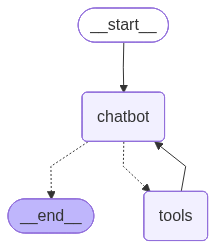

In [27]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [28]:
user_input="Hi there!, My name is John"

events=graph.stream(
     {"messages": [("user", user_input)]},stream_mode="values"
)

for event in events:
  event["messages"][-1].pretty_print()#pretty print is to get a proper output

================================ Human Message =================================

Hi there!, My name is John
================================== Ai Message ==================================

Hi John! 👋 Nice to meet you. How can I assist you today?


In [29]:
user_input = "what is RLHF."

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [("user", user_input)]},stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

what is RLHF.
================================== Ai Message ==================================

**RLHF — Reinforcement Learning from Human Feedback**

---

### 1. What it is  
Reinforcement Learning from Human Feedback (RLHF) is a machine‑learning paradigm that combines **reinforcement learning (RL)** with **human‑generated evaluative signals** to train an AI system—most commonly large language models (LLMs)—to behave in ways that align with human preferences, values, or instructions.

Instead of relying solely on a manually crafted reward function (which is often impossible to specify for complex, open‑ended tasks), RLHF lets humans provide the “reward” by judging model outputs. The algorithm then uses those judgments to shape the model’s policy through RL.

---

### 2. Why RLHF is needed  

| Problem | Traditional RL solution | Why it fails for language/AI alignment |
|---------|------------------------